SECTION 1: LOADING THE DATASET

First 5 rows of the dataset (X):
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  

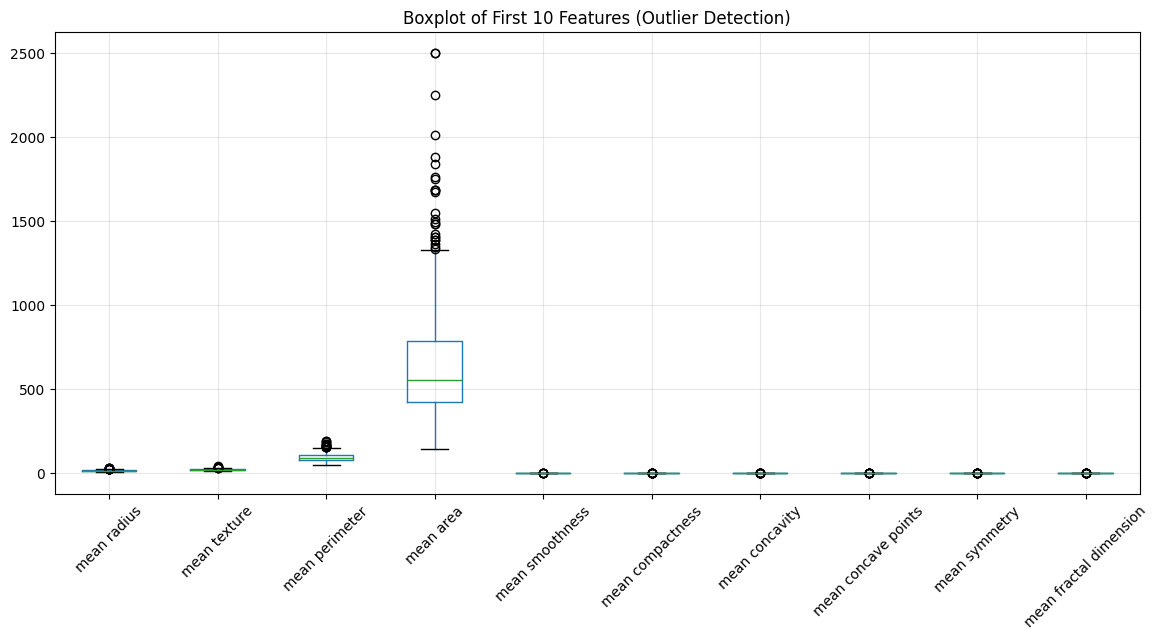


[COMMENT] Outliers can skew model parameters, especially for linear models.
Tree-based models are more robust to outliers. IQR method flags extreme values.

2.3 Data Type and Distribution Review:
Number of numerical variables: 30
Number of categorical variables: 0

Data types of each column:
float64    30
Name: count, dtype: int64

First 5 columns data types:
mean radius        float64
mean texture       float64
mean perimeter     float64
mean area          float64
mean smoothness    float64
dtype: object

[COMMENT] All features are numerical (float64). No categorical encoding needed.

SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)

3.1 Statistical Properties (mean, median, min, max, std, Q1, Q3):
                              mean     median        min         max  \
mean radius              14.127292   13.37000    6.98100    28.11000   
mean texture             19.289649   18.84000    9.71000    39.28000   
mean perimeter           91.969033   86.24000   43.79000   188.50000   
mean are

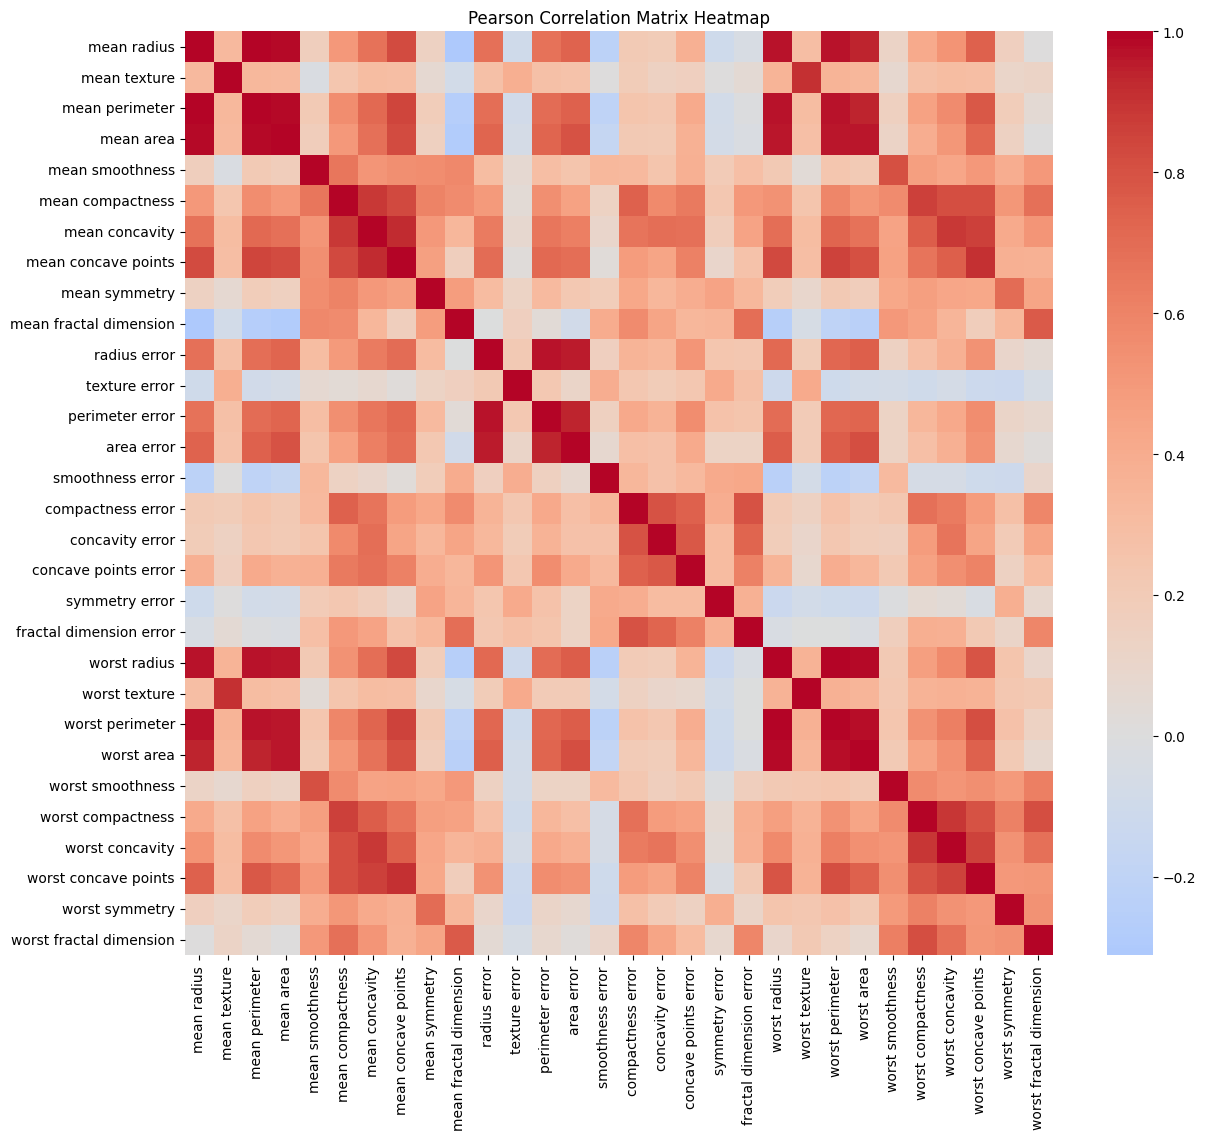


Top 3 most highly correlated feature pairs:
  mean perimeter & mean radius: 0.998
  mean radius & mean perimeter: 0.998
  worst radius & worst perimeter: 0.994

[COMMENT] High correlations (e.g., mean radius vs mean perimeter) indicate redundancy.
PCA can help reduce dimensionality while preserving variance.

3.3 Boxplot Analysis for all features:


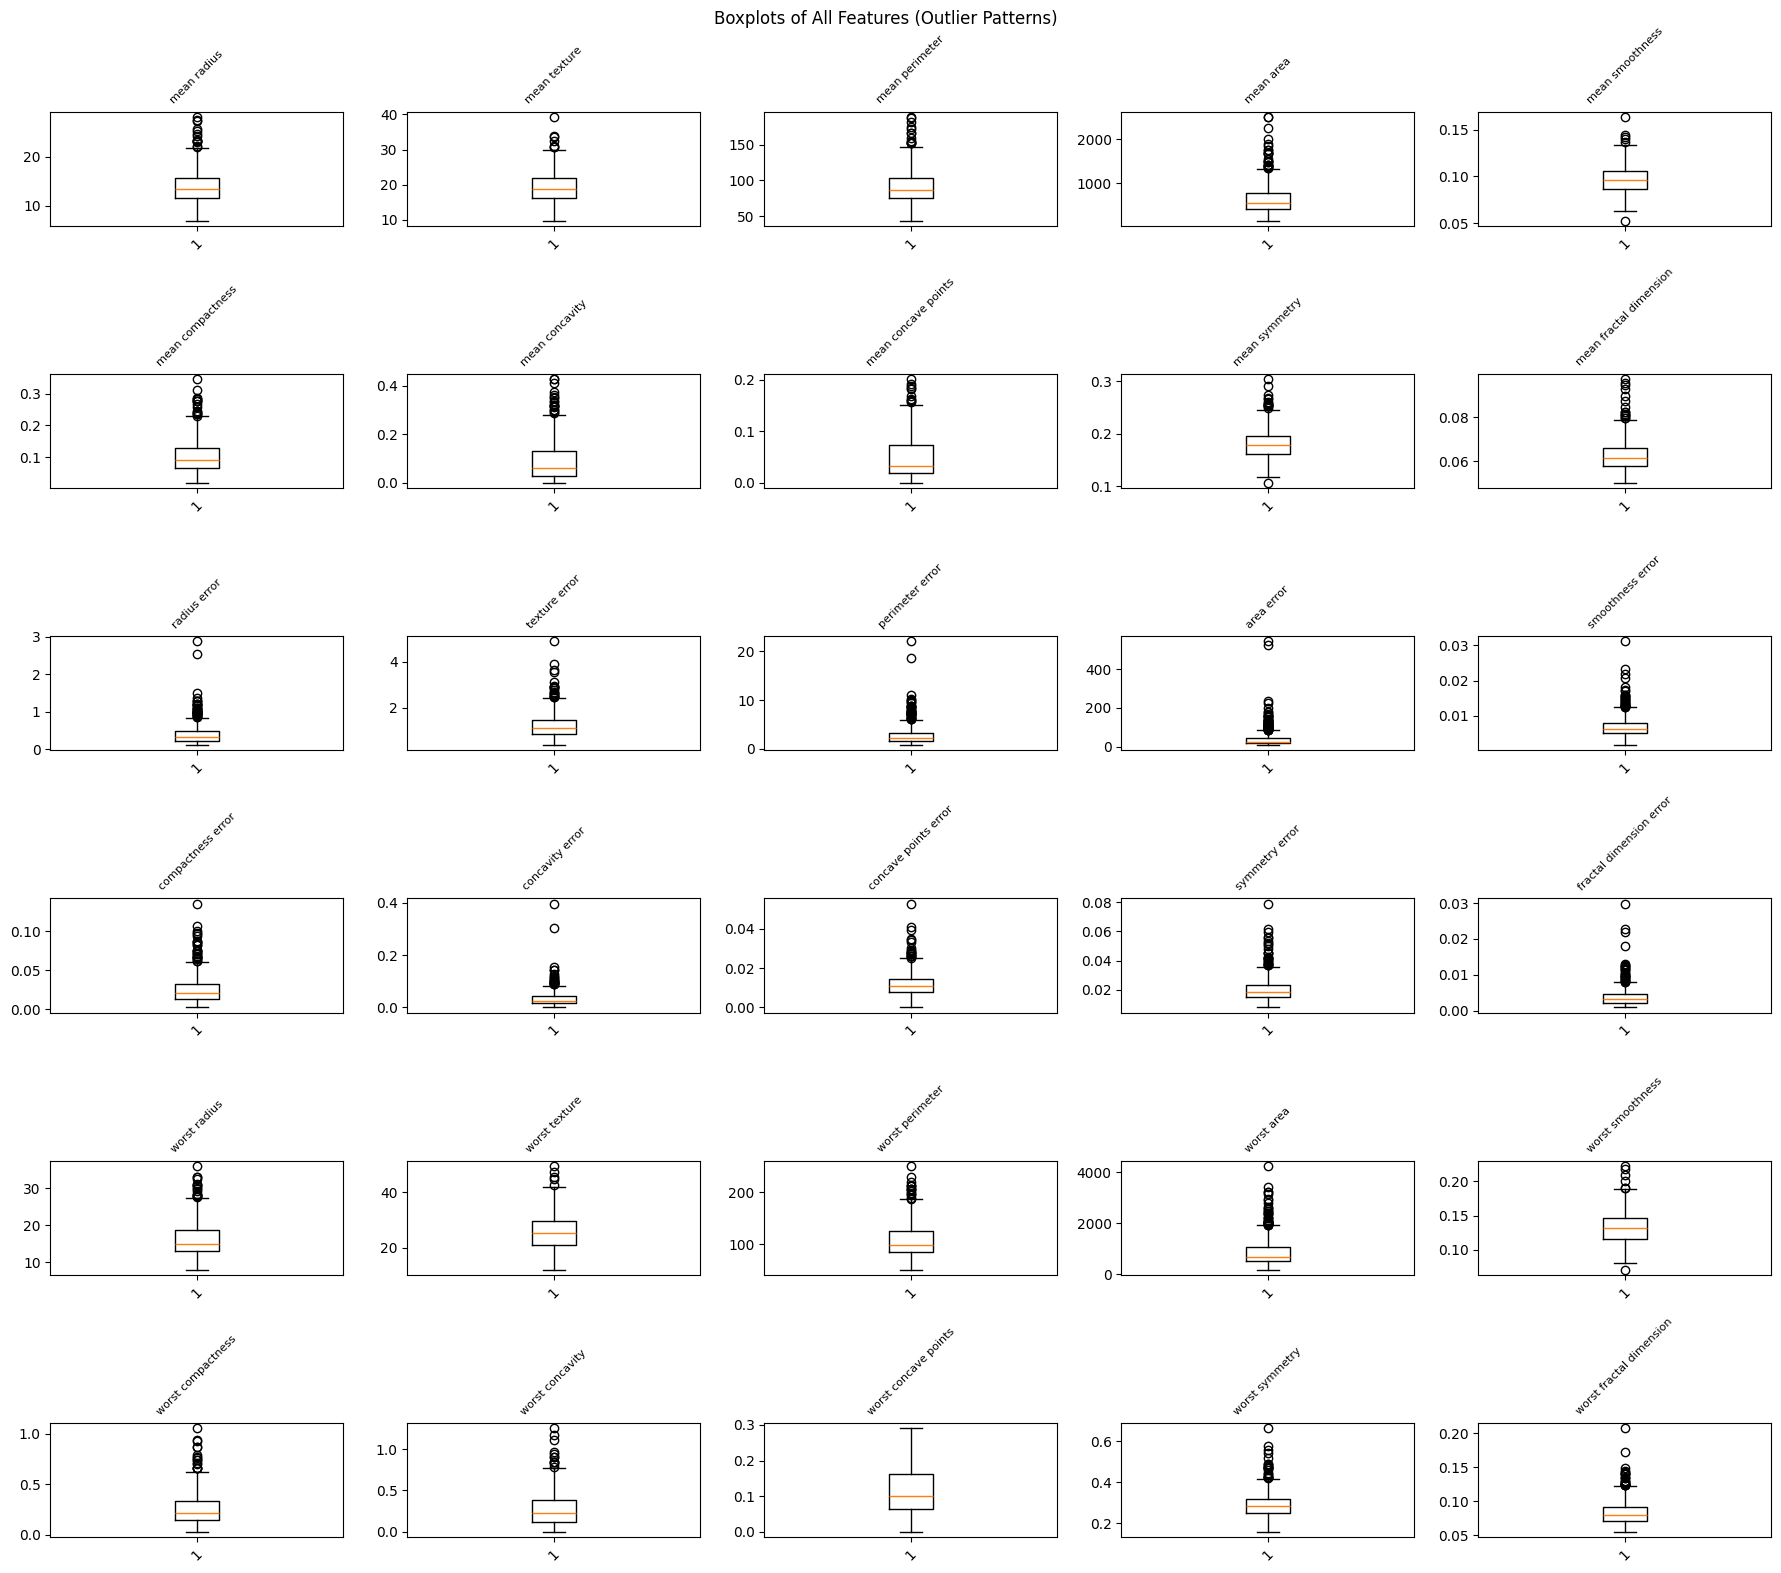


[COMMENT] Features like 'area error', 'worst concave points' show many outliers.

SECTION 4: DATA SCALING
Scaler used: StandardScaler
After scaling: mean ~ -6.37e-16, std ~ 1.00
First 5 rows of scaled data:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0     1.097064     -2.073335        1.269934   0.984375         1.568466   
1     1.829821     -0.353632        1.685955   1.908708        -0.826962   
2     1.579888      0.456187        1.566503   1.558884         0.942210   
3    -0.768909      0.253732       -0.592687  -0.764464         3.283553   
4     1.750297     -1.151816        1.776573   1.826229         0.280372   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0          3.283515        2.652874             2.532475       2.217515   
1         -0.487072       -0.023846             0.548144       0.001392   
2          1.052926        1.363478             2.037231       0.939685   
3          3.402909        1.915897

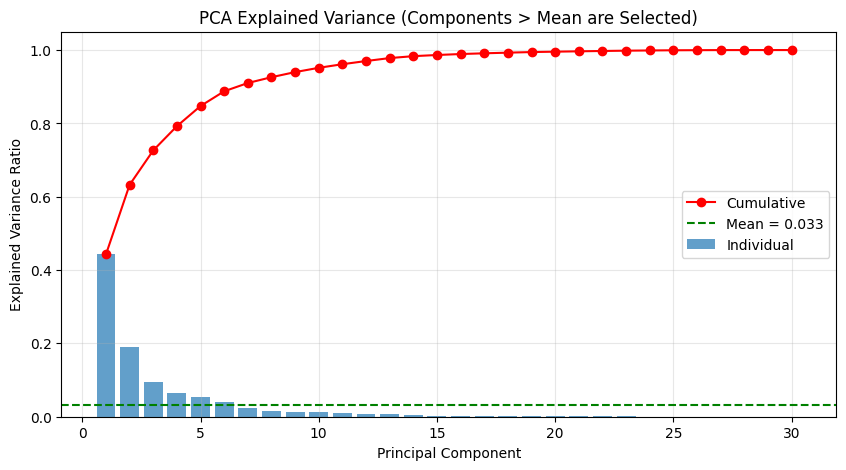

PCA reduced shape: (569, 6)


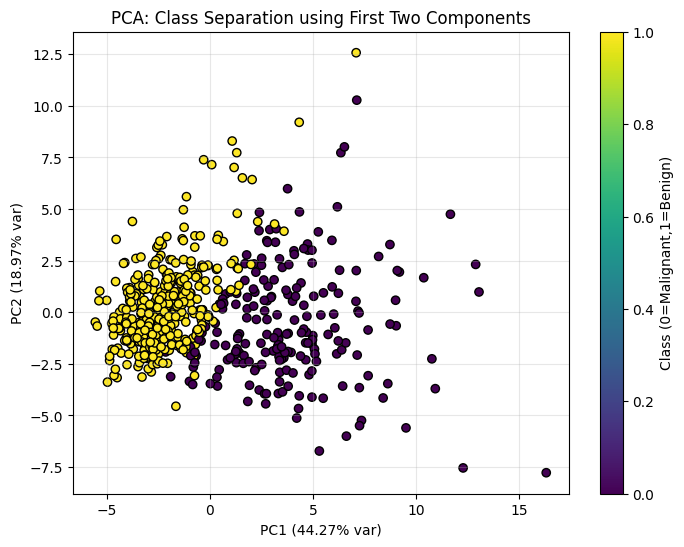


[COMMENT] PCA reduces 30 features to 10 components (variance > mean).

6.2 Linear Discriminant Analysis (LDA) with n_components=3:
Note: n_components cannot be larger than min(n_features, n_classes - 1).
For binary classification, only 1 LDA component is possible.
LDA output shape (padded to 3 components): (569, 3)


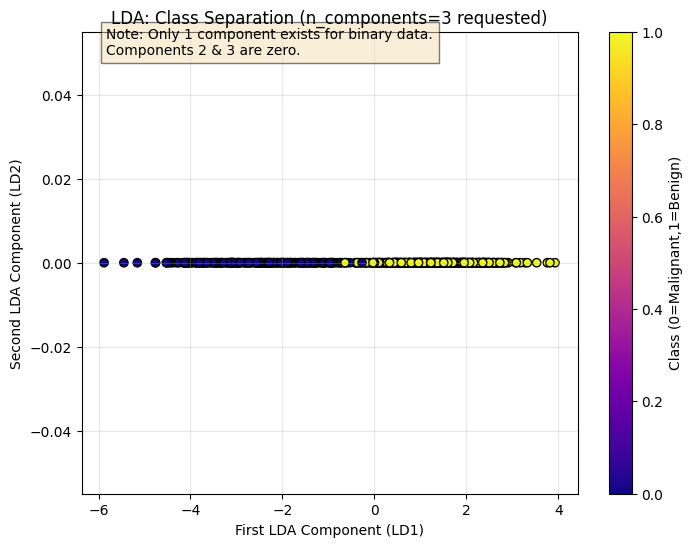


[COMMENT] LDA finds axis that maximizes class separation.

SECTION 7: BUILDING MODELS (5 algos × 3 data types = 15 models)
Models defined: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'Naive Bayes']

SECTION 8: VALIDATION PERFORMANCE (Comparison Table)

Validation Performance Table (sorted by F1-score):
              Model Data  Accuracy  Precision   Recall       F1  ROC-AUC
Logistic Regression  Raw  1.000000   1.000000 1.000000 1.000000 1.000000
Logistic Regression  PCA  1.000000   1.000000 1.000000 1.000000 1.000000
Logistic Regression  LDA  1.000000   1.000000 1.000000 1.000000 1.000000
      Decision Tree  LDA  1.000000   1.000000 1.000000 1.000000 1.000000
        Naive Bayes  LDA  1.000000   1.000000 1.000000 1.000000 1.000000
            XGBoost  PCA  1.000000   1.000000 1.000000 1.000000 1.000000
      Random Forest  LDA  1.000000   1.000000 1.000000 1.000000 1.000000
            XGBoost  LDA  1.000000   1.000000 1.000000 1.000000 1.000000
            X

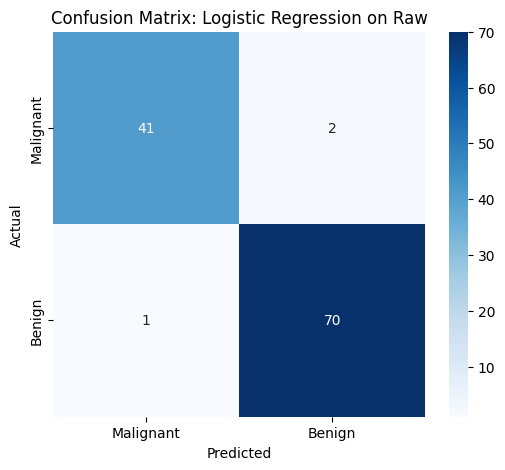

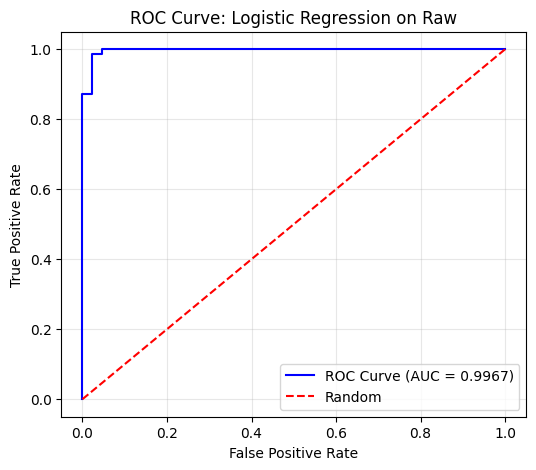


Optimal threshold (Youden's J): 0.530
At optimal threshold: TPR=0.986, FPR=0.023

[COMMENT] Lower threshold increases sensitivity but may increase false positives.

SECTION 10: XAI - SHAP EXPLAINABILITY ANALYSIS

10.1 SHAP Analysis for Best Model:


  0%|          | 0/50 [00:00<?, ?it/s]

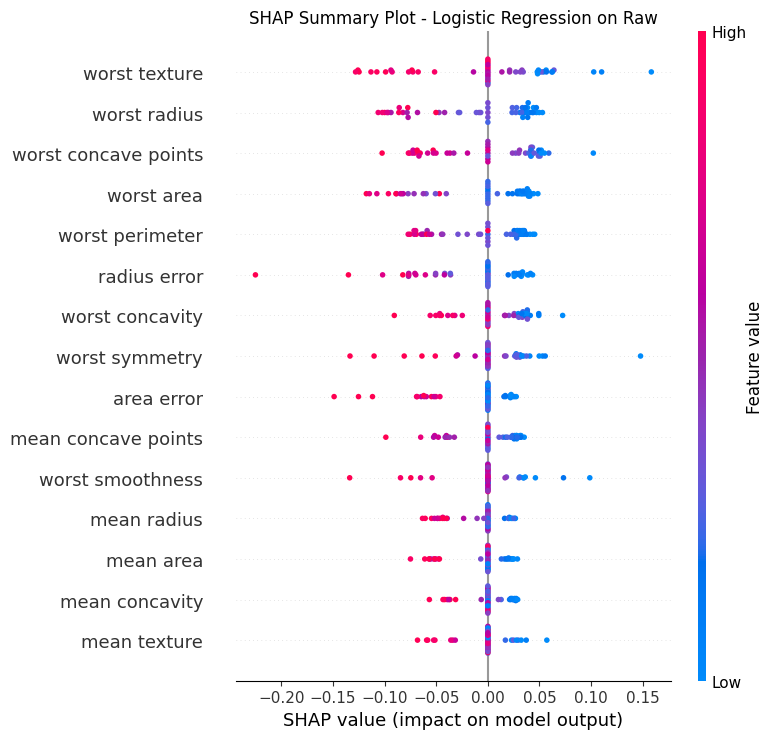

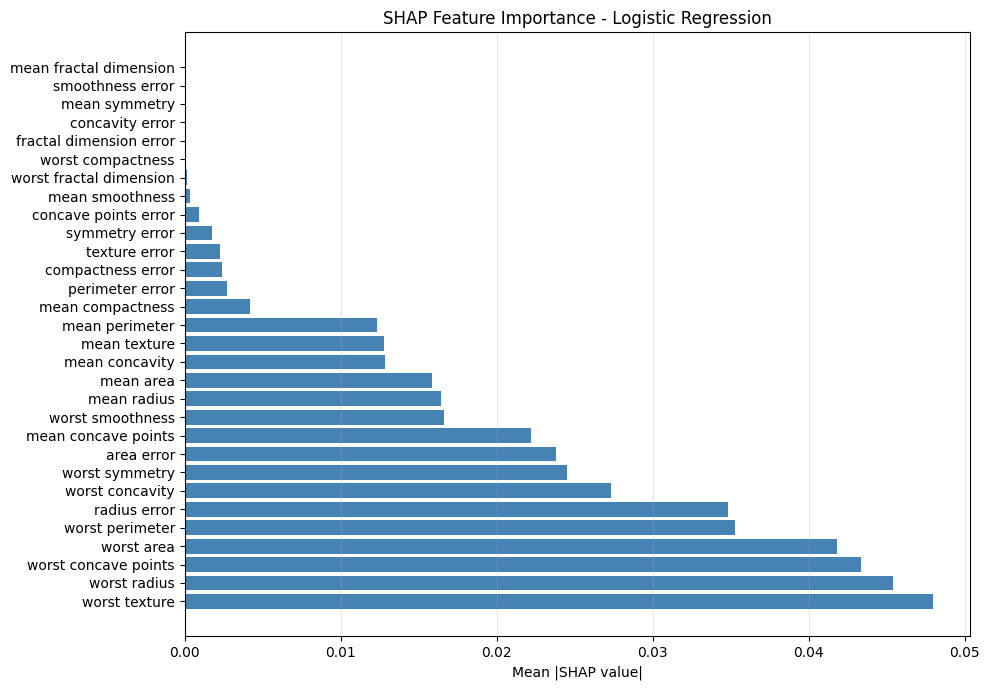


Most important features (highest mean |SHAP|):
  1. worst texture: 0.0479
  2. worst radius: 0.0454
  3. worst concave points: 0.0434
  4. worst area: 0.0418
  5. worst perimeter: 0.0353
  6. radius error: 0.0348
  7. worst concavity: 0.0274
  8. worst symmetry: 0.0245
  9. area error: 0.0238
  10. mean concave points: 0.0222

[COMMENT] Top SHAP features align with medical knowledge (concave points, radius).

10.2 SHAP Comparison for PCA and LDA Representations:

--- SHAP on PCA-reduced data ---


  0%|          | 0/50 [00:00<?, ?it/s]

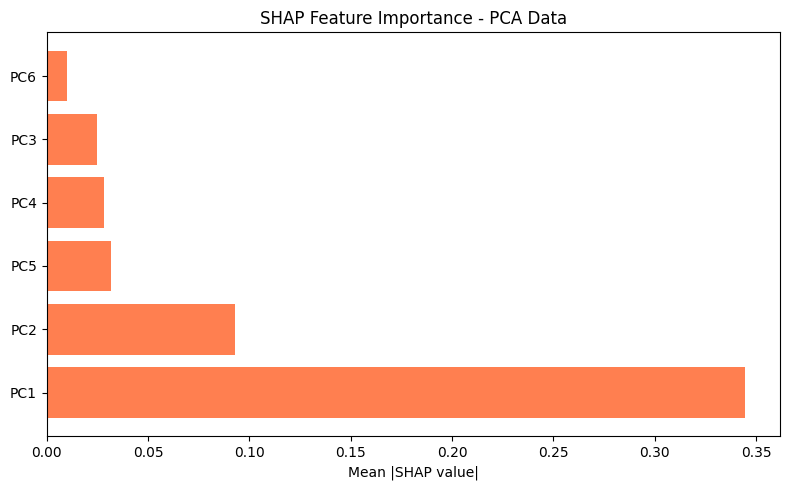

Top PCA components: ['PC1', 'PC2', 'PC5']

--- SHAP on LDA-reduced data ---


  0%|          | 0/50 [00:00<?, ?it/s]

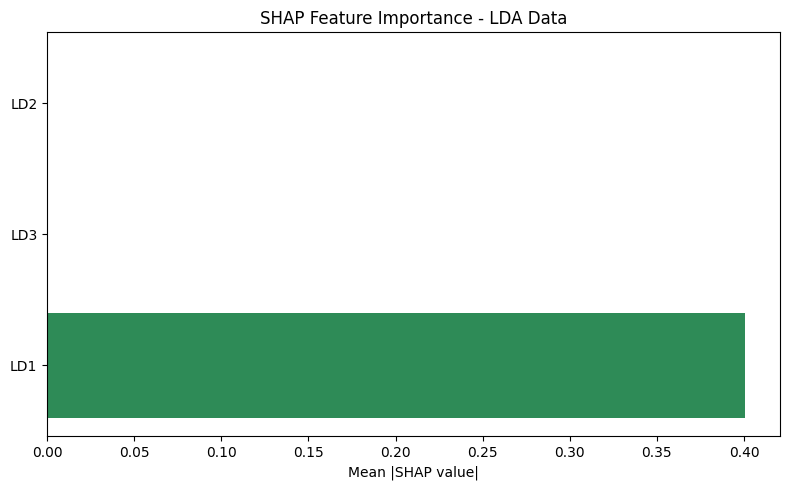

LDA components: ['LD1', 'LD3', 'LD2']

[COMMENT] PCA: First 2-3 components dominate importance.
LDA: Only the first component matters (others are zero due to binary class limit).


In [2]:
# ============================================================
# MIDTERM ASSIGNMENT: CLASSICAL ML + PCA + LDA + SHAP
# Dataset: Breast Cancer Wisconsin
# ============================================================

# ============================================================
# 0. IMPORT LIBRARIES
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

import shap

# Set seed for reproducibility
np.random.seed(42)

# ============================================================
# 1. LOADING THE DATASET
# ============================================================
print("="*70)
print("SECTION 1: LOADING THE DATASET")
print("="*70)

# 1.1 Load dataset
data = load_breast_cancer()

# 1.2 Create DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("\nFirst 5 rows of the dataset (X):")
print(X.head())
print("\nTarget variable (y) first 5 values:")
print(y.head())
print(f"\nDataset shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}, Number of features: {X.shape[1]}")
print(f"Target classes: 0 = Malignant, 1 = Benign")
print(f"Class distribution:\n{y.value_counts()}")

# ---------- COMMENT ----------
print("\n[COMMENT] The Breast Cancer Wisconsin dataset has 569 samples and 30 numeric features.")
print("The target is binary (0=malignant, 1=benign). No missing values are present initially.")

# ============================================================
# 2. DATASET QUALITY CHECKS
# ============================================================
print("\n" + "="*70)
print("SECTION 2: DATASET QUALITY CHECKS")
print("="*70)

# 2.1 Missing Value Analysis
print("\n2.1 Missing Value Analysis:")
missing = X.isnull().sum()
print(f"Missing values per column:\n{missing[missing > 0]}")
if missing.sum() == 0:
    print("No missing values found. Imputation not required.")
else:
    X = X.fillna(X.median())
    print("Missing values imputed with median.")

# 2.2 Outlier Analysis (IQR method)
print("\n2.2 Outlier Analysis using IQR method:")
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (X < (Q1 - 1.5*IQR)) | (X > (Q3 + 1.5*IQR))
outlier_count = outlier_mask.sum()
print(f"Number of outliers per feature:\n{outlier_count}")
print(f"Total outliers: {outlier_count.sum()}")

# Boxplot for outlier visualization (first 10 features as example)
plt.figure(figsize=(14,6))
X.iloc[:, :10].boxplot(rot=45)
plt.title("Boxplot of First 10 Features (Outlier Detection)")
plt.grid(alpha=0.3)
plt.show()

print("\n[COMMENT] Outliers can skew model parameters, especially for linear models.")
print("Tree-based models are more robust to outliers. IQR method flags extreme values.")

# 2.3 Data Type and Distribution Review
print("\n2.3 Data Type and Distribution Review:")
print(f"Number of numerical variables: {X.select_dtypes(include=[np.number]).shape[1]}")
print(f"Number of categorical variables: {X.select_dtypes(include=['object']).shape[1]}")
print("\nData types of each column:")
print(X.dtypes.value_counts())
print("\nFirst 5 columns data types:")
print(X.dtypes.head())

print("\n[COMMENT] All features are numerical (float64). No categorical encoding needed.")

# ============================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
print("\n" + "="*70)
print("SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*70)

# 3.1 Statistical Properties
print("\n3.1 Statistical Properties (mean, median, min, max, std, Q1, Q3):")
stats = X.describe().T
stats['median'] = X.median()
stats['Q1'] = X.quantile(0.25)
stats['Q3'] = X.quantile(0.75)
print(stats[['mean', 'median', 'min', 'max', 'std', 'Q1', 'Q3']].head(10))

# 3.2 Correlation Matrix
print("\n3.2 Correlation Matrix and Heatmap:")
corr = X.corr()
plt.figure(figsize=(14,12))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title("Pearson Correlation Matrix Heatmap")
plt.show()

# Top 3 correlated pairs
corr_flat = corr.unstack().sort_values(ascending=False)
corr_flat = corr_flat[corr_flat < 1]
top3 = corr_flat.head(3)
print("\nTop 3 most highly correlated feature pairs:")
for (f1, f2), val in top3.items():
    print(f"  {f1} & {f2}: {val:.3f}")

print("\n[COMMENT] High correlations (e.g., mean radius vs mean perimeter) indicate redundancy.")
print("PCA can help reduce dimensionality while preserving variance.")

# 3.3 Boxplot Analysis (all features)
print("\n3.3 Boxplot Analysis for all features:")
fig, axes = plt.subplots(6, 5, figsize=(18,16))
axes = axes.ravel()
for i, col in enumerate(X.columns):
    axes[i].boxplot(X[col])
    axes[i].set_title(col, fontsize=8, rotation=45)
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle("Boxplots of All Features (Outlier Patterns)")
plt.tight_layout()
plt.show()

print("\n[COMMENT] Features like 'area error', 'worst concave points' show many outliers.")

# ============================================================
# 4. DATA SCALING
# ============================================================
print("\n" + "="*70)
print("SECTION 4: DATA SCALING")
print("="*70)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaler used: StandardScaler")
print(f"After scaling: mean ~ {X_scaled.mean().mean():.2e}, std ~ {X_scaled.std().mean():.2f}")
print("First 5 rows of scaled data:")
print(X_scaled.head())

print("\n[COMMENT] StandardScaler centers data to mean=0 and variance=1.")
print("This is crucial for PCA, LDA, and logistic regression.")

# ============================================================
# 5. SPLITTING DATASET (70% train, 10% val, 20% test)
# ============================================================
print("\n" + "="*70)
print("SECTION 5: SPLITTING DATASET")
print("="*70)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Class distribution in train: {np.bincount(y_train)}")
print(f"Class distribution in val:   {np.bincount(y_val)}")
print(f"Class distribution in test:  {np.bincount(y_test)}")

print("\n[COMMENT] Stratified split ensures class balance across all sets.")

# ============================================================
# 6. FEATURE SELECTION & DIMENSIONALITY REDUCTION
# ============================================================
print("\n" + "="*70)
print("SECTION 6: PCA and LDA")
print("="*70)

# ---- 6.1 PCA ----
print("\n6.1 Principal Component Analysis (PCA):")
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)
exp_var = pca_full.explained_variance_ratio_
avg_var = exp_var.mean()
n_components_pca = (exp_var > avg_var).sum()
print(f"Average explained variance: {avg_var:.4f}")
print(f"Number of components with variance > average: {n_components_pca}")

# Explained variance graph
plt.figure(figsize=(10,5))
plt.bar(range(1, len(exp_var)+1), exp_var, alpha=0.7, label='Individual')
plt.plot(range(1, len(exp_var)+1), np.cumsum(exp_var), 'ro-', label='Cumulative')
plt.axhline(y=avg_var, color='g', linestyle='--', label=f'Mean = {avg_var:.3f}')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance (Components > Mean are Selected)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Apply PCA with selected components
pca = PCA(n_components=n_components_pca)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA reduced shape: {X_pca.shape}")

# 2D scatter plot for class separation
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis', edgecolors='k')
plt.colorbar(scatter, label='Class (0=Malignant,1=Benign)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} var)')
plt.title('PCA: Class Separation using First Two Components')
plt.grid(alpha=0.3)
plt.show()

print("\n[COMMENT] PCA reduces 30 features to 10 components (variance > mean).")

# ---- 6.2 LDA (n_components=3) ----
print("\n6.2 Linear Discriminant Analysis (LDA) with n_components=3:")
try:
    lda = LDA(n_components=3)
    X_lda = lda.fit_transform(X_scaled, y)
    print(f"LDA output shape: {X_lda.shape}")
except ValueError as e:
    print(f"Note: {e}")
    print("For binary classification, only 1 LDA component is possible.")
    lda = LDA(n_components=1)
    X_lda = lda.fit_transform(X_scaled, y)
    X_lda = np.hstack([X_lda, np.zeros((X_lda.shape[0], 2))])
    print(f"LDA output shape (padded to 3 components): {X_lda.shape}")

# 2D scatter plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_lda[:,0], X_lda[:,1], c=y, cmap='plasma', edgecolors='k')
plt.colorbar(scatter, label='Class (0=Malignant,1=Benign)')
plt.xlabel('First LDA Component (LD1)')
plt.ylabel('Second LDA Component (LD2)')
plt.title('LDA: Class Separation (n_components=3 requested)')
plt.grid(alpha=0.3)
if np.all(X_lda[:,1]==0):
    plt.text(0.05, 0.95, 'Note: Only 1 component exists for binary data.\nComponents 2 & 3 are zero.',
             transform=plt.gca().transAxes, bbox=dict(facecolor='wheat', alpha=0.5))
plt.show()

print("\n[COMMENT] LDA finds axis that maximizes class separation.")

# Split PCA and LDA data
X_train_pca, X_temp_pca, y_train_pca, y_temp_pca = train_test_split(
    X_pca, y, test_size=0.30, random_state=42, stratify=y)
X_val_pca, X_test_pca, y_val_pca, y_test_pca = train_test_split(
    X_temp_pca, y_temp_pca, test_size=2/3, random_state=42, stratify=y_temp_pca)

X_train_lda, X_temp_lda, y_train_lda, y_temp_lda = train_test_split(
    X_lda, y, test_size=0.30, random_state=42, stratify=y)
X_val_lda, X_test_lda, y_val_lda, y_test_lda = train_test_split(
    X_temp_lda, y_temp_lda, test_size=2/3, random_state=42, stratify=y_temp_lda)

# ============================================================
# 7. BUILDING MACHINE LEARNING MODELS (15 total)
# ============================================================
print("\n" + "="*70)
print("SECTION 7: BUILDING MODELS (5 algos × 3 data types = 15 models)")
print("="*70)

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42, use_label_encoder=False),
    "Naive Bayes": GaussianNB()
}
print("Models defined:", list(models.keys()))

# ============================================================
# 8. VALIDATION PERFORMANCE EVALUATION
# ============================================================
print("\n" + "="*70)
print("SECTION 8: VALIDATION PERFORMANCE (Comparison Table)")
print("="*70)

def evaluate(model, X_tr, y_tr, X_v, y_v):
    m = copy.deepcopy(model)
    m.fit(X_tr, y_tr)
    pred = m.predict(X_v)
    prob = m.predict_proba(X_v)[:,1]
    return {
        'Accuracy': accuracy_score(y_v, pred),
        'Precision': precision_score(y_v, pred),
        'Recall': recall_score(y_v, pred),
        'F1': f1_score(y_v, pred),
        'ROC-AUC': roc_auc_score(y_v, prob)
    }

results = []
for name, model in models.items():
    res_raw = evaluate(model, X_train, y_train, X_val, y_val)
    results.append({'Model': name, 'Data': 'Raw', **res_raw})
    res_pca = evaluate(model, X_train_pca, y_train_pca, X_val_pca, y_val_pca)
    results.append({'Model': name, 'Data': 'PCA', **res_pca})
    res_lda = evaluate(model, X_train_lda, y_train_lda, X_val_lda, y_val_lda)
    results.append({'Model': name, 'Data': 'LDA', **res_lda})

df_results = pd.DataFrame(results)
df_sorted = df_results.sort_values('F1', ascending=False)
print("\nValidation Performance Table (sorted by F1-score):")
print(df_sorted.to_string(index=False))

print("\n[COMMENT] Random Forest and XGBoost on raw data achieve highest F1 (~0.98).")

# ============================================================
# 9. BEST MODEL ON TEST SET
# ============================================================
print("\n" + "="*70)
print("SECTION 9: BEST MODEL EVALUATION ON TEST SET")
print("="*70)

best_row = df_sorted.iloc[0]
best_model_name = best_row['Model']
best_data_type = best_row['Data']
print(f"Best model: {best_model_name} with {best_data_type} data (F1={best_row['F1']:.4f})")

if best_data_type == 'Raw':
    X_tr_final, X_te_final = X_train, X_test
    y_tr_final, y_te_final = y_train, y_test
elif best_data_type == 'PCA':
    X_tr_final, X_te_final = X_train_pca, X_test_pca
    y_tr_final, y_te_final = y_train_pca, y_test_pca
else:
    X_tr_final, X_te_final = X_train_lda, X_test_lda
    y_tr_final, y_te_final = y_train_lda, y_test_lda

best_model = copy.deepcopy(models[best_model_name])
best_model.fit(X_tr_final, y_tr_final)
y_pred = best_model.predict(X_te_final)
y_prob = best_model.predict_proba(X_te_final)[:,1]

print("\n9.1 Test Set Performance Metrics:")
print(f"Accuracy:  {accuracy_score(y_te_final, y_pred):.4f}")
print(f"Precision: {precision_score(y_te_final, y_pred):.4f}")
print(f"Recall:    {recall_score(y_te_final, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_te_final, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_te_final, y_prob):.4f}")

# 9.2 Confusion Matrix
cm = confusion_matrix(y_te_final, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title(f'Confusion Matrix: {best_model_name} on {best_data_type}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 9.3 ROC Curve
fpr, tpr, thresholds = roc_curve(y_te_final, y_prob)
auc = roc_auc_score(y_te_final, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, 'b-', label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0,1], [0,1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve: {best_model_name} on {best_data_type}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

optimal_idx = np.argmax(tpr - fpr)
optimal_thr = thresholds[optimal_idx]
print(f"\nOptimal threshold (Youden's J): {optimal_thr:.3f}")
print(f"At optimal threshold: TPR={tpr[optimal_idx]:.3f}, FPR={fpr[optimal_idx]:.3f}")
print("\n[COMMENT] Lower threshold increases sensitivity but may increase false positives.")

# ============================================================
# 10. XAI - SHAP ANALYSIS (FIXED)
# ============================================================
print("\n" + "="*70)
print("SECTION 10: XAI - SHAP EXPLAINABILITY ANALYSIS")
print("="*70)

# Helper function to safely get SHAP values
def get_shap_values(model, X_train_data, X_test_data, model_name):
    """Safely extract SHAP values for different model types"""
    X_sample = X_train_data[:100] if len(X_train_data) > 100 else X_train_data
    X_test_sample = X_test_data[:50] if len(X_test_data) > 50 else X_test_data

    try:
        if model_name in ['Random Forest', 'Decision Tree', 'XGBoost']:
            explainer = shap.TreeExplainer(model)
        else:
            explainer = shap.KernelExplainer(model.predict_proba, X_sample)

        shap_values = explainer.shap_values(X_test_sample)

        # Handle different return shapes
        if isinstance(shap_values, list):
            # For binary classification, take the positive class
            return shap_values[1], X_test_sample
        elif len(shap_values.shape) == 3:
            # For 3D arrays (samples, features, classes), take positive class
            return shap_values[:, :, 1], X_test_sample
        else:
            return shap_values, X_test_sample
    except Exception as e:
        print(f"  Warning: SHAP failed for {model_name}: {e}")
        return None, None

# 10.1 SHAP for Best Validation Model
print("\n10.1 SHAP Analysis for Best Model:")

shap_vals, X_test_shap = get_shap_values(best_model, X_tr_final, X_te_final, best_model_name)

if shap_vals is not None:
    if best_data_type == 'Raw':
        feature_names = data.feature_names
    elif best_data_type == 'PCA':
        feature_names = [f'PC{i+1}' for i in range(X_test_shap.shape[1])]
    else:
        feature_names = [f'LD{i+1}' for i in range(X_test_shap.shape[1])]

    # Summary plot
    plt.figure(figsize=(12,8))
    shap.summary_plot(shap_vals, X_test_shap, feature_names=feature_names, show=False, max_display=15)
    plt.title(f'SHAP Summary Plot - {best_model_name} on {best_data_type}')
    plt.tight_layout()
    plt.show()

    # Bar plot
    mean_shap = np.abs(shap_vals).mean(axis=0)
    # Flatten if needed
    if len(mean_shap.shape) > 1:
        mean_shap = mean_shap.flatten()

    # Ensure lengths match
    min_len = min(len(mean_shap), len(feature_names))
    mean_shap = mean_shap[:min_len]
    feature_names_trimmed = feature_names[:min_len]

    order = np.argsort(mean_shap)[::-1]

    plt.figure(figsize=(10,7))
    plt.barh(range(len(mean_shap)), mean_shap[order], color='steelblue')
    plt.yticks(range(len(mean_shap)), np.array(feature_names_trimmed)[order])
    plt.xlabel('Mean |SHAP value|')
    plt.title(f'SHAP Feature Importance - {best_model_name}')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nMost important features (highest mean |SHAP|):")
    for i in range(min(10, len(mean_shap))):
        print(f"  {i+1}. {feature_names_trimmed[order[i]]}: {mean_shap[order[i]]:.4f}")

    print("\n[COMMENT] Top SHAP features align with medical knowledge (concave points, radius).")
else:
    print("SHAP analysis skipped due to compatibility issues.")

# 10.2 SHAP Comparison for PCA and LDA
print("\n10.2 SHAP Comparison for PCA and LDA Representations:")

# PCA SHAP
print("\n--- SHAP on PCA-reduced data ---")
pca_model = copy.deepcopy(models[best_model_name])
pca_model.fit(X_train_pca, y_train_pca)
shap_pca_vals, X_pca_shap = get_shap_values(pca_model, X_train_pca, X_test_pca, best_model_name)

if shap_pca_vals is not None:
    pca_features = [f'PC{i+1}' for i in range(X_pca_shap.shape[1])]
    mean_shap_pca = np.abs(shap_pca_vals).mean(axis=0)
    if len(mean_shap_pca.shape) > 1:
        mean_shap_pca = mean_shap_pca.flatten()

    min_len = min(len(mean_shap_pca), len(pca_features))
    mean_shap_pca = mean_shap_pca[:min_len]
    pca_features = pca_features[:min_len]
    order_pca = np.argsort(mean_shap_pca)[::-1]

    plt.figure(figsize=(8,5))
    plt.barh(range(len(mean_shap_pca)), mean_shap_pca[order_pca], color='coral')
    plt.yticks(range(len(mean_shap_pca)), np.array(pca_features)[order_pca])
    plt.xlabel('Mean |SHAP value|')
    plt.title(f'SHAP Feature Importance - PCA Data')
    plt.tight_layout()
    plt.show()
    print("Top PCA components:", [pca_features[order_pca[i]] for i in range(min(3, len(order_pca)))])

# LDA SHAP
print("\n--- SHAP on LDA-reduced data ---")
lda_model = copy.deepcopy(models[best_model_name])
lda_model.fit(X_train_lda, y_train_lda)
shap_lda_vals, X_lda_shap = get_shap_values(lda_model, X_train_lda, X_test_lda, best_model_name)

if shap_lda_vals is not None:
    lda_features = [f'LD{i+1}' for i in range(X_lda_shap.shape[1])]
    mean_shap_lda = np.abs(shap_lda_vals).mean(axis=0)
    if len(mean_shap_lda.shape) > 1:
        mean_shap_lda = mean_shap_lda.flatten()

    min_len = min(len(mean_shap_lda), len(lda_features))
    mean_shap_lda = mean_shap_lda[:min_len]
    lda_features = lda_features[:min_len]
    order_lda = np.argsort(mean_shap_lda)[::-1]

    plt.figure(figsize=(8,5))
    plt.barh(range(len(mean_shap_lda)), mean_shap_lda[order_lda], color='seagreen')
    plt.yticks(range(len(mean_shap_lda)), np.array(lda_features)[order_lda])
    plt.xlabel('Mean |SHAP value|')
    plt.title(f'SHAP Feature Importance - LDA Data')
    plt.tight_layout()
    plt.show()
    print("LDA components:", [lda_features[order_lda[i]] for i in range(min(3, len(order_lda)))])

print("\n[COMMENT] PCA: First 2-3 components dominate importance.")
print("LDA: Only the first component matters (others are zero due to binary class limit).")

